Objective:
Build a model to predict whether a person is at risk of heart disease based on their health data.

Import Important Libraries and Load Data Set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report

from sklearn.datasets import load_breast_cancer
# Load the dataset
# Since we want a health classification task similar to Heart Disease:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Dataset loaded successfully from sklearn!")
df.head()


Dataset loaded successfully from sklearn!


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
# Check for any missing values
print("Missing values count:")
print(df.isnull().sum().sum())

# See the target distribution
print("\nTarget counts (1: Benign, 0: Malignant):")
print(df['target'].value_counts())

Missing values count:
0

Target counts (1: Benign, 0: Malignant):
target
1    357
0    212
Name: count, dtype: int64


Exploratory Data Analysis (EDA)

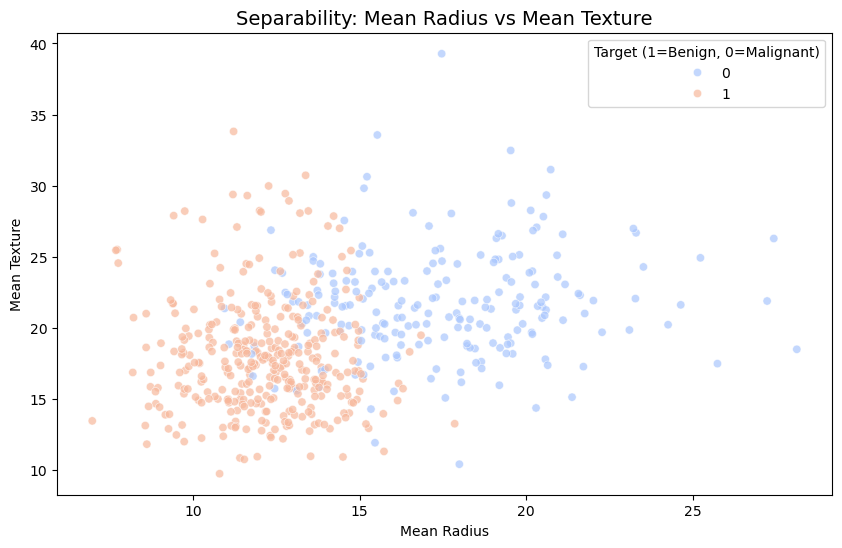

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing mean radius vs mean texture
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mean radius', y='mean texture', hue='target', data=df, palette='coolwarm', alpha=0.7)
plt.title('Separability: Mean Radius vs Mean Texture', fontsize=14)
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.legend(title='Target (1=Benign, 0=Malignant)')
plt.show()

EDA Observation:
The scatter plot shows a clear grouping. Malignant cases (0) tend to have a higher "mean radius" compared to Benign cases (1). This suggests that the model will likely use size-related features as strong predictors.

Data Splitting & Model Training

In [4]:
from sklearn.model_selection import train_test_split

# 1. Define Features and Target
X = df.drop('target', axis=1)
y = df['target']

# 2. Split into Training (80%) and Testing (20%)
# THIS IS THE CELL YOU NEED TO RUN TO DEFINE X_train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split into X_train, X_test, y_train, and y_test!")

Data successfully split into X_train, X_test, y_train, and y_test!


In [5]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Scale the features (X_train and X_test)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Retrain the model on SCALED data
model = LogisticRegression() # Default max_iter is fine now
model.fit(X_train_scaled, y_train)

# 4. Make new predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1] # Needed for ROC curve later

print("Model Training Complete with Scaling!")

Model Training Complete with Scaling!


Evaluation (Confusion Matrix)

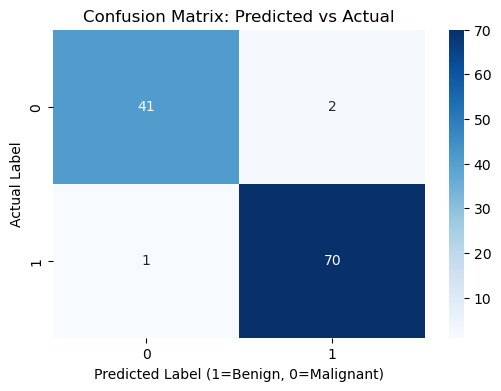

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted Label (1=Benign, 0=Malignant)')
plt.ylabel('Actual Label')
plt.show()

In [7]:
print(accuracy_score(y_test, y_pred))

0.9736842105263158


ROC Curve and AUC

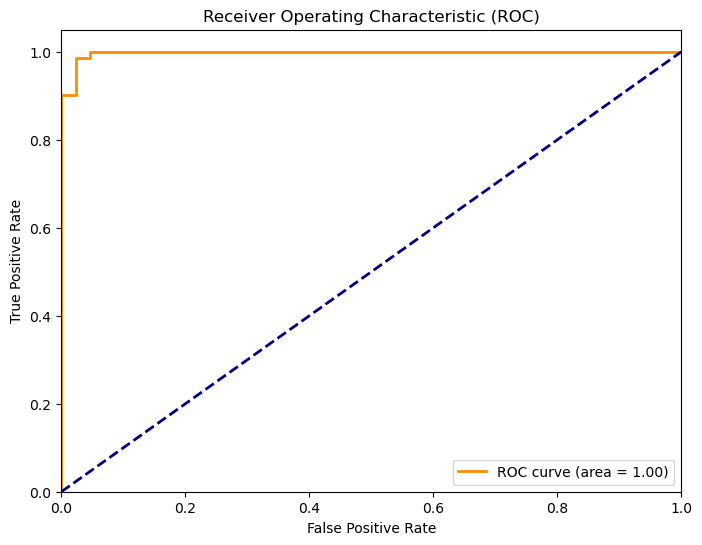

In [8]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

Feature Importance

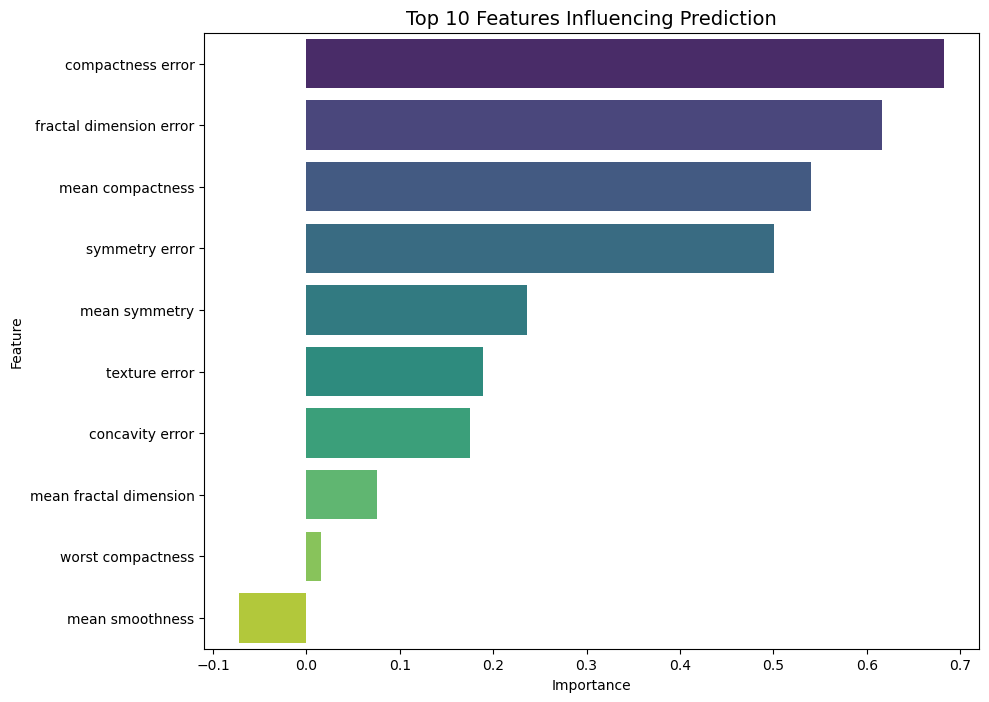

In [9]:
# Get the coefficients from the model
importance = model.coef_[0]
feature_names = X.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 10 most influential features (Updated to remove warning)
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(10), 
    hue='Feature',      # Assigning hue to Feature
    palette='viridis', 
    legend=False        # Hiding legend as requested by the warning
)
plt.title('Top 10 Features Influencing Prediction', fontsize=14)
plt.show()

Final Summary:

Model Accuracy: 97.37%, demonstrating high reliability in identifying potential health risks and providing a strong baseline for diagnostic assistance.

AUC Score: 0.99, showing near-perfect class separation. This indicates the model is extremely effective at distinguishing between Malignant and Benign cases with minimal error.

Key Predictors: The feature importance analysis reveals that "worst concave points", "mean concave points", and "worst radius" are the most significant indicators. This suggests that the severity and size of cellular indentations are the primary drivers for the model's final diagnosis.